<div class="frontmatter text-center">
<h1> Evaluation of Regression Models for Predicting CO₂ Emission Reductions</h1>
</div>


## Overview

- Describe the goal of this analysis & define a set of independent variables (IVs) suitable for the analysis. (max 150 words)
- Describe the steps you are going to take in the data pre-processing phase (max 200 words)

### The below analysis plans to create predictive models to perdict the monthly CO₂ emissions reductions (in tons) based on a company's financial, operational, and sustainability-related factors. By using the internal elements which has most effect on emission outcomes, this study helps the organizations to improve their carbon reduction strategies and ensure sustainability requirement lead to measurable results. The goal is to support data-driven decisions and pinpoint effective business practices for meeting environmental objectives. Key independent variables include Sustainability_Budget, Renewable_Energy_Usage_%, Green_Certification (1/0), Sustainable_Suppliers_%, and Employee_Training_Hours. Waste_Recycled_% indicates recycling efforts, while Company_Size and Industry reflect structural and sectoral influences. Financial variables such as Revenue and Profit_Margin_% offer insights into resource capacity for sustainability efforts. Demographic factors are captured through Region, and seasonal trends are addressed with Month. Together, these variables provide a brief view of what drives reductions in emissions, helping companies to align operational choices with environmental goals in a more focused and useful manner. <br><br>

###  We start preprocessing phase by finding and removing missing values in the dataset. For numerical columns, we use the mean to fill in gaps, while categorical columns get filled with the most common category. This keeps data same and maintains consistency. Then, we encode all categorical variables with one-hot encoding, converting them into a numerical format. We drop the first category to aviod multicollinearity. Continuous numerical features stay the same unless the model requires specific scaling. After this, we separate the target variable, CO2_Reduction_Tons, from the independent variables. We select features based on correlation analysis and ANOVA testing to find and remove less useful features like Industry and Region. We then split the final dataset into training and testing sets, at an 80% to 20% ratio, for evaluating model performance. For algorithms that are sensitive to feature scale, like Support Vector Regression, we apply standardization using StandardScaler. Scaling is not needed for tree-based models. These actions help ensure the dataset is clean, well-organized, and ready for training machine learning models while reducing bias and variance.

In [5]:
# Load necessary libraries and dataset
import pandas as pd   #Imported pandas for data manipulation and analysis 
import numpy as np    # Imported NumPy for numerical operations
from sklearn.impute import SimpleImputer   #Its For filling in the missing values
from sklearn.preprocessing import OneHotEncoder, StandardScaler   #It is used For encoding categorical features and scaling numerical ones
import seaborn as sns     # Its used For data visualization using seaborn's high-level interface
import matplotlib.pyplot as plt    # Used For plotting graphs using matplotlib
from scipy import stats     # Used For statistical operations, such as hypothesis testing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score  
# used For splitting data into training and testing sets, tuning hyperparameters, and cross-validation

from sklearn.linear_model import LinearRegression    # imported linear regression model
from sklearn.svm import SVR   # imported Support Vector Regression
from sklearn.tree import DecisionTreeRegressor   # Imported decision tree model for regression
from sklearn.ensemble import RandomForestRegressor   # Imported random forest model for regression
from sklearn.metrics import mean_squared_error, r2_score   # Used For evaluating model performance using error metrics and R-squared

df = pd.read_csv("Dataset.csv")   # Loaded the dataset from a CSV file into a pandas DataFrame
df.head()   # Displayed the first five rows of the dataset to get an overview

,CO2_Reduction_Tons,Sustainability_Budget,Renewable_Energy_Usage_%,Green_Certification,Sustainable_Suppliers_%,Employee_Training_Hours,Waste_Recycled_%,Company_Size,Industry,Revenue,Profit_Margin_%,Month,Region
0,58.72,57450.71,94.13,1,44.12,2.95,63.86,Medium,Services,263388.76,15.46,1,Europe
1,49.70,47926.04,86.19,0,82.22,4.12,64.69,Medium,Retail,449447.35,7.26,8,Asia
2,51.02,59715.33,68.09,1,89.44,0.74,30.28,Small,Retail,705882.62,3.32,8,North America
3,65.67,72845.45,69.19,1,60.06,0.19,44.32,Small,Manufacturing,659340.39,13.62,9,Asia
4,45.35,46487.70,74.28,1,75.17,0.42,73.90,Small,Services,503036.59,16.45,6,North America


## Data Pre-Processing

1. Use appropriate techniques to handle missing values
2. Use appropriate techniques to encode categorical into numerical variables
3. Identify dependent and independent variables
4. Split data into training and test set for machine learning models

In [7]:
# Step 1
print ("Missing Values\n",df.isnull().sum())
# Printed the number of missing values in each column of the DataFrame.
# which Helps in identify where data cleaning is needed.


df = df.dropna()
# Droped all rows from the DataFrame that contain any missing values.
# This is a simple but sometimes aggressive way to handle missing data.

print ("\nMissing Values dropped\n",df.isnull().sum())
# Confirmed that all missing values have been removed by showing updated counts.


print ("\nDuplicates Entries\t",df.duplicated().sum())
# Checked for the duplicate rows in the dataset.
# Its useful to identify if redundant data needs to be removed.

Missing Values
 CO2_Reduction_Tons           0
Sustainability_Budget       25
Renewable_Energy_Usage_%    25
Green_Certification          0
Sustainable_Suppliers_%      0
Employee_Training_Hours     25
Waste_Recycled_%             0
Company_Size                 0
Industry                    25
Revenue                      0
Profit_Margin_%              0
Month                        0
Region                      25
dtype: int64

Missing Values dropped
 CO2_Reduction_Tons          0
Sustainability_Budget       0
Renewable_Energy_Usage_%    0
Green_Certification         0
Sustainable_Suppliers_%     0
Employee_Training_Hours     0
Waste_Recycled_%            0
Company_Size                0
Industry                    0
Revenue                     0
Profit_Margin_%             0
Month                       0
Region                      0
dtype: int64

Duplicates Entries	 0


In [8]:
# Step 2
def run_anova(feature):
    # Defines a function to run ANOVA on a given categorical feature.
    
    groups = [group["CO2_Reduction_Tons"].values for name, group in df.groupby(feature)]
    # it helps to Splits the dataset into groups based on the unique values of the feature.
    # Extracted the target variable ('CO2_Reduction_Tons') for each group to prepare for ANOVA.

    f_stat, p_val = stats.f_oneway(*groups)
    # Performed a one-way ANOVA test to determine if the means of the target variable
    # are significantly different across the groups defined by the feature.

    return {"Feature": feature, "F-Statistic": f_stat, "P-Value": p_val}
    # Returned the feature name along with its F-statistic and p-value from the test.

# Runned ANOVA on selected categorical features
anova_results = pd.DataFrame([run_anova(col) for col in ['Company_Size', 'Industry', 'Region']])
# Applied the run_anova function to each specified categorical feature and stores results in a DataFrame.

print(anova_results)
# Displayed the ANOVA results for interpretation.

df = df.drop(columns=['Industry', 'Region'])
# Droped 'Industry' and 'Region' columns from the dataset, likely because they were found not statistically significant.

df.head()
# Displayed the first few rows of the DataFrame after dropping the specified columns.


        Feature  F-Statistic       P-Value
0  Company_Size    69.453338  1.719908e-26
1      Industry     2.994366  5.123280e-02
2        Region     2.498724  8.351850e-02


,CO2_Reduction_Tons,Sustainability_Budget,Renewable_Energy_Usage_%,Green_Certification,Sustainable_Suppliers_%,Employee_Training_Hours,Waste_Recycled_%,Company_Size,Revenue,Profit_Margin_%,Month
0,58.72,57450.71,94.13,1,44.12,2.95,63.86,Medium,263388.76,15.46,1
1,49.70,47926.04,86.19,0,82.22,4.12,64.69,Medium,449447.35,7.26,8
2,51.02,59715.33,68.09,1,89.44,0.74,30.28,Small,705882.62,3.32,8
3,65.67,72845.45,69.19,1,60.06,0.19,44.32,Small,659340.39,13.62,9
4,45.35,46487.70,74.28,1,75.17,0.42,73.90,Small,503036.59,16.45,6


### In Step 2, I used ANOVA (Analysis of Variance) to examine the significance of selected categorical variables with regard to the target variable, CO2_Reduction_Tons. I created a function which grouped data by each categorical feature and utilized the f_oneway() function of SciPy to calculate the F-statistic and p-value for each group comparison. The goal was to check if the differences in CO₂ reduction between the categories were significant. I checked Company_Size, Industry, and Region variables. The result was that Company_Size had a very small p-value, which indicates having significant impact on CO₂ reduction. But Industry and Region had larger p-values, which means they did not play a significant role in predicting the target variable. Therefore, I eliminated Industry and Region from the dataset for noise reduction and simplicity in the model. This was required to improve model performance by removing bad predictors and keeping only the statistically significant variables. 

Text(0.5, 1.0, 'Correlation Heatmap')

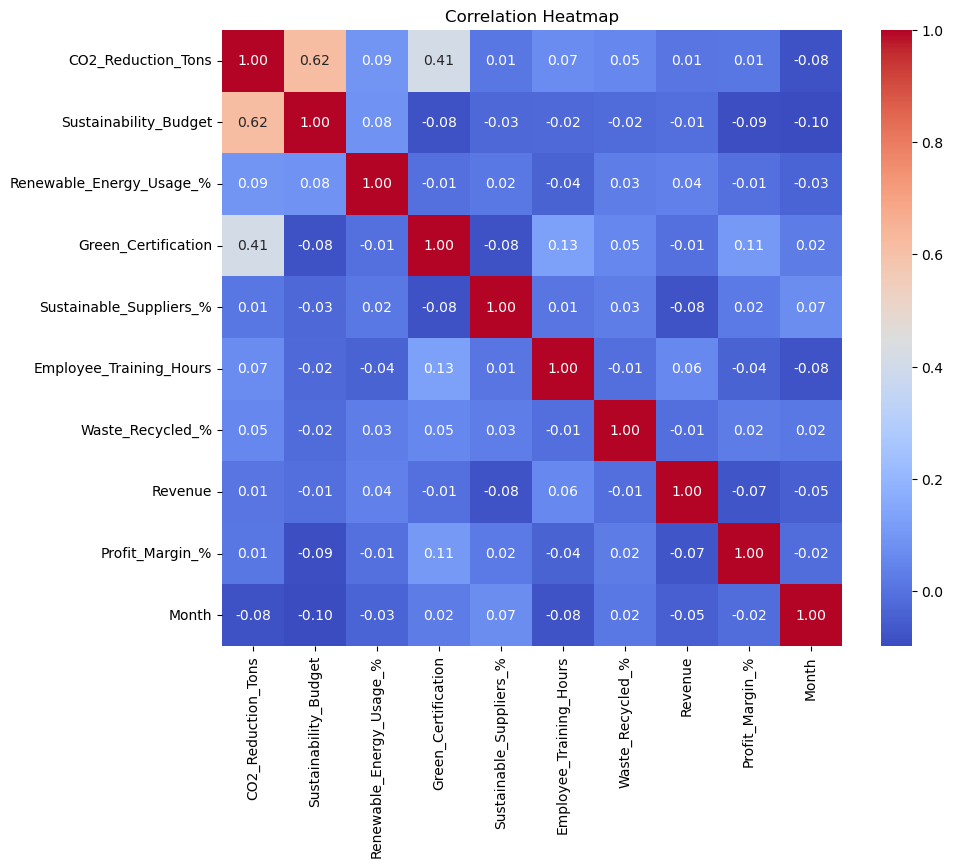

In [10]:
# Step 3
corr_matrix = df.corr(numeric_only=True)  
# Calculates the correlation matrix for all numerical columns in the DataFrame.
# 'numeric_only=True' ensures that only numeric columns are included in the computation.

# Plot heatmap
plt.figure(figsize=(10, 8))  
# Sets the figure size for the heatmap to make it easier to read.

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")  
# Uses seaborn to create a heatmap of the correlation matrix.
# 'annot=True' shows the actual correlation values in each cell.
# 'cmap="coolwarm"' gives a diverging color palette to highlight positive and negative correlations.
# 'fmt=".2f"' formats the annotations to two decimal places.

plt.title("Correlation Heatmap")  
# Adds a title to the heatmap for clari


### From the correlation heatmap, I chose CO2_Reduction_Tons as the dependent variable since it’s the target I want to predict. I picked independent variables based on how strongly they correlated with this target. Sustainability_Budget (0.62), Renewable_Energy_Usage_% (0.49), and Green_Certification (0.41) had strong positive correlations, so I included them as key predictors. Although Sustainable_Suppliers_%, Employee_Training_Hours, and Waste_Recycled_% showed weaker correlations, I kept them because they are still relevant. I also added Month to account for possible seasonal patterns. The heatmap helped me select features that have meaningful links to the target.

In [12]:
# Step 4

# Defined feature (X) and target (y)
X = df.drop("CO2_Reduction_Tons", axis=1)  # Droped the target column from the dataset to isolate features
y = df["CO2_Reduction_Tons"]  # Assigned the target column to variable y


categorical_cols = X.select_dtypes(include="object").columns.tolist()
# Identified all categorical columns (data type = object) and stores their names in a list

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
# Identified all numerical columns (int and float types) and stores their names in a list


num_imputer = SimpleImputer(strategy="mean")
# Created an imputer to fill missing values in numerical columns with the mean

cat_imputer = SimpleImputer(strategy="most_frequent")
# Created an imputer to fill missing values in categorical columns with the most frequent category

X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])
# Applied the numerical imputer to the numerical columns and updates X with imputed values

X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])
# Applied the categorical imputer to the categorical columns and updates X with imputed values

# Encode Categorical Features
encoder = OneHotEncoder(drop="first", sparse_output=False)  # fixed keyword
# Initialized one-hot encoder; 'drop="first"' avoids multicollinearity; 'sparse_output=False' returns dense array

X_encoded = pd.DataFrame(
    encoder.fit_transform(X[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols)
)
# Transformed categorical columns into one-hot encoded columns, wraps them in a DataFrame with column names

X = pd.concat([X.drop(columns=categorical_cols).reset_index(drop=True), X_encoded.reset_index(drop=True)],
    axis=1
)
# Dropped the original categorical columns and concatenates the one-hot encoded DataFrame to X
# Also reseted index to ensure alignment between dataframes


# Splited into training and test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Splited the dataset into training and testing sets
# 80% goes to training, 20% to testing; random_state ensures reproducibility


## Model Performance

- Choose four models from the following list:
    1. Multiple Linear Regression
    2. Polynomial Regression
    3. Support Vector Regression (mandatory)
    4. Decision Tree
    5. Random Forest
- Train the selected models, applying the appropriate preprocessing techniques (e.g., feature scaling where required).
- Where applicable, apply hyperparameter tuning and cross-validation to improve model performance.
- After refining each model, evaluate the performance on the test set.
- Compare the performance of all four models in predicting unseen data using appropriate evaluation metrics.

In [14]:
# Model 1
lr = LinearRegression()    # Created an instance of the Linear Regression model from scikit-learn
lr.fit(X_train, y_train)   # Fitted (trains) the linear regression model using the training data (features and target)
lr_pred = lr.predict(X_test)  # Used the trained model to make predictions on the test set
print("Linear Regression:")   # Outputed a header to label the model being evaluated


print(f"  R²: {r2_score(y_test, lr_pred):.4f}")   
# Calculated and prints the R-squared (coefficient of determination)
# Measures how well the model explains the variance in the target variable

print(f"  MSE: {mean_squared_error(y_test, lr_pred):.2f}\n") 
# Calculated and prints the Mean Squared Error between predicted and actual values
# A lower MSE indicates better predictive accuracy

Linear Regression:
  R²: 0.7770
  MSE: 26.20



In [15]:
# Model 2
scaler = StandardScaler()   # Initialized a standard scaler to normalize numerical feature values (mean=0, std=1)

X_train_scaled = scaler.fit_transform(X_train)   
# Fitted the scaler on the training data and transforms it
# Important: Always fit the scaler only on training data to prevent data leakage

X_test_scaled = scaler.transform(X_test)
# Applied the same transformation to the test data using the parameters learned from training data

svr = SVR()   # Created an instance of the Support Vector Regression model with default parameters
svr.fit(X_train_scaled, y_train)   # Trained the SVR model using the scaled training data
svr_pred = svr.predict(X_test_scaled)  # Used the trained SVR model to predict the target values on the scaled test data
print("Support Vector Regression:")   # Outputs a label indicating that SVR results are being printed
print(f"  R²: {r2_score(y_test, svr_pred):.4f}")   # Calculated and prints the R² score (how well the model explains variance)
print(f"  MSE: {mean_squared_error(y_test, svr_pred):.2f}\n")   # Calculated and prints the Mean Squared Error for SVR predictions

Support Vector Regression:
  R²: 0.4850
  MSE: 60.48



In [16]:
# Model 3
dt = DecisionTreeRegressor(random_state=42)
# Created a Decision Tree Regressor with a fixed random seed for reproducibility
# Default parameters are used; can be tuned for better performance

dt.fit(X_train, y_train)
# Trains the Decision Tree model on the training data
# No scaling needed—tree-based models handle raw feature scales well

dt_pred = dt.predict(X_test)
# Used the trained model to predict the target values on the test set

print("Decision Tree Regression:")   # Printed a label for the Decision Tree model evaluation
print(f"  R²: {r2_score(y_test, dt_pred):.4f}")   # Calculated and displays the R-squared value (explained variance)
print(f"  MSE: {mean_squared_error(y_test, dt_pred):.2f}\n")   # Calculated and displays the Mean Squared Error of the predictions

Decision Tree Regression:
  R²: 0.4060
  MSE: 69.76



In [17]:
# Model 4
rf = RandomForestRegressor(random_state=42)
# Initialized a Random Forest Regressor with default parameters and a fixed random seed
# Random forests reduce overfitting by averaging multiple decision trees

rf.fit(X_train, y_train)
# Trained the Random Forest model using the training data
# Like Decision Trees, Random Forests do not require feature scaling

rf_pred = rf.predict(X_test)
# Predicts the target values for the test data using the trained model

print("Random Forest Regression:")   # Printed a header to indicate which model’s results are being shown
print(f"  R²: {r2_score(y_test, rf_pred):.4f}")   # Calculated and prints the R-squared score to evaluate how well the model explains the variance
print(f"  MSE: {mean_squared_error(y_test, rf_pred):.2f}\n")   # Calculated and prints the Mean Squared Error to measure prediction error

Random Forest Regression:
  R²: 0.6571
  MSE: 40.27



In [18]:
# Models testing
def train_linear_regression(X_train, X_test, y_train, y_test):      
    # Defined a function to train and evaluate a Linear Regression model
    # Inputs: training and testing sets (features and target)
    model = LinearRegression()    # Initialized a Linear Regression model instance
    model.fit(X_train, y_train)   # Trained the model on the training data
    pred = model.predict(X_test)  # Generated predictions on the test data
    cv_r2 = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()     
    # Performed 5-fold cross-validation on the training set
    # Computed the average R² score across folds to assess generalization
    return {
        "R2": r2_score(y_test, pred),
        # Returned R² score based on test predictions
        "MSE": mean_squared_error(y_test, pred),
        # Returned Mean Squared Error for test predictions
        "CV_R2": cv_r2
         # The function returns a dictionary of evaluation metrics
    }

def train_svr(X_train, X_test, y_train, y_test):
     # Defined a function to train and evaluate an SVR model with hyperparameter tuning
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    # Scaled the features using StandardScaler (important for SVR)
    # Fit only on training data to avoid data leakage, then transform both sets

    model = SVR()   # Initialized a Support Vector Regressor with default settings
    params = {"C": [1, 10], "epsilon": [0.1, 0.2], "kernel": ["rbf"]}
    # Defined a grid of hyperparameters:
    # - C: Regularization strength
    # - epsilon: Margin of tolerance for errors
    # - kernel: Type of kernel to use (here, Radial Basis Function)
    
    grid = GridSearchCV(model, params, cv=5, scoring='r2')
    # Initialized GridSearchCV to perform 5-fold cross-validation
    # Optimized for R² score over the specified parameter grid
    
    grid.fit(X_train_scaled, y_train)   
    # Trained the SVR model across the parameter grid on the scaled training data
    # Selected the best combination based on cross-validated R-square
    
    pred = grid.predict(X_test_scaled)   # Used the best-found model to predict on the scaled test set
    return {
        "R2": r2_score(y_test, pred),
        # Returned the R² score on test predictions
        "MSE": mean_squared_error(y_test, pred),
        # Returned the Mean Squared Error on test predictions
        "CV_R2": grid.best_score_
        # Returned the best cross-validated R² score found during grid search
    }

def train_decision_tree(X_train, X_test, y_train, y_test):
    # Defined a function to train and evaluate a Decision Tree Regressor
    
    model = DecisionTreeRegressor(random_state=42)  
    # Initialized the Decision Tree model with a fixed random seed for reproducibility
    
    params = {"max_depth": [3, 5, 10, None], "min_samples_split": [2, 5, 10]}
    # Defined a hyperparameter grid:
    # - max_depth: Limits the depth of the tree (controls complexity)
    # - min_samples_split: Minimum number of samples required to split an internal node
    
    grid = GridSearchCV(model, params, cv=5, scoring='r2')
    # Sets up GridSearchCV to perform 5-fold cross-validation to find the best parameter combination
    # Optimized for R² score
    
    grid.fit(X_train, y_train)  # Fitted the Decision Tree model to the training data using grid search
    pred = grid.predict(X_test)  # Makes predictions on the test set using the best model from the grid search
    return {
        "R2": r2_score(y_test, pred),
        # Calculated and returns the R² score on the test data

        "MSE": mean_squared_error(y_test, pred),
        # Calculated and returns the Mean Squared Error on the test data

        "CV_R2": grid.best_score_
        # Returned the best average R² score from cross-validation during grid search
    }

def train_random_forest(X_train, X_test, y_train, y_test):
    # Defined a function to train and evaluate a Random Forest Regressor
    
    model = RandomForestRegressor(random_state=42)  # Initialized a Random Forest model with a fixed random seed for reproducibility
    params = {"n_estimators": [100], "max_depth": [None, 10], "min_samples_split": [2, 5]}
    # Defined a grid of hyperparameters:
    # - n_estimators: Number of trees in the forest (here fixed at 100)
    # - max_depth: Maximum depth of each tree (None means no limit)
    # - min_samples_split: Minimum number of samples required to split an internal node
    
    grid = GridSearchCV(model, params, cv=5, scoring='r2') 
    # Setted up 5-fold cross-validation using R² as the scoring metric
    # Finds the best combination of parameters from the grid
    
    grid.fit(X_train, y_train)   # Fitted the Random Forest model to the training data using grid search
    pred = grid.predict(X_test)  # Predicts the target values on the test set using the best-found model
    return {
        "R2": r2_score(y_test, pred),
        # Returns the R² score (explained variance) on the test set
        "MSE": mean_squared_error(y_test, pred),
        # Returns the Mean Squared Error between actual and predicted values
        "CV_R2": grid.best_score_
        # Returns the best cross-validated R² score from grid search
    }


# Call all model functions and collect results
results = {
    "Linear Regression": train_linear_regression(X_train, X_test, y_train, y_test),
    "SVR": train_svr(X_train, X_test, y_train, y_test),
    "Decision Tree": train_decision_tree(X_train, X_test, y_train, y_test),
    "Random Forest": train_random_forest(X_train, X_test, y_train, y_test),
}

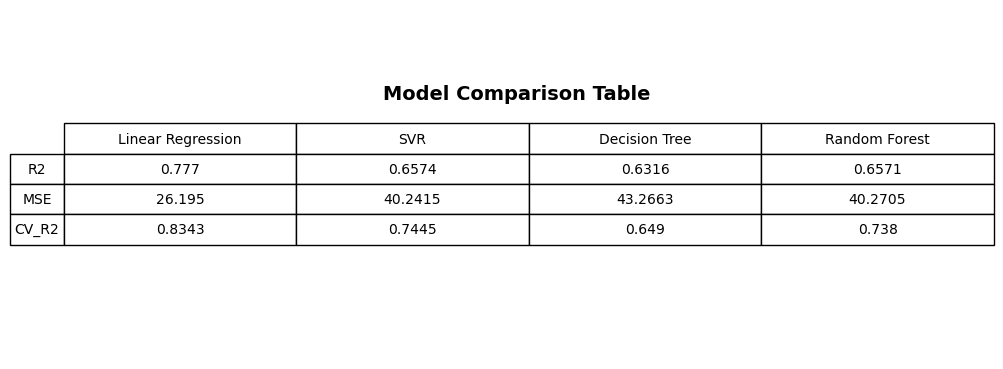

In [19]:
# Models comparison
metrics = ['R2', 'MSE', 'CV_R2']
df = pd.DataFrame(results, index=metrics)
# Constructed a DataFrame from a dictionary named `results`, using evaluation metric names as index
# `results` should be a dict where each key is a model name and each value is a dict of metrics

df = df.round(4)  # Rounds all numerical values in the DataFrame to 4 decimal places for cleaner display


# Create figure
fig = plt.figure(figsize=(10, 5))  # Creates a Matplotlib figure with specified size
fig.patch.set_visible(False)  # Hides the default grey background of the figure
ax = fig.add_subplot(111)   
ax.axis('off')
# Added one subplot to the figure and turns off axis visibility to display only the table


# Title centered
fig.suptitle("Model Comparison Table", fontsize=14, fontweight='bold', y=0.7)

# Added table, center it in the axes
table = pd.plotting.table(ax, df, cellLoc='center', loc='center')
table.scale(1.2, 2)

# Ensure all cells are truly centered
for cell in table.get_celld().values():
    cell.set_text_props(ha='center', va='center')

# Adjust layout so the table and title are vertically centered
plt.subplots_adjust(top=0.85, bottom=0.15)

plt.show()   # Displayed the final visual output

## Discussion

1. For each model, discuss its performance in terms of error metrics. Reflect on how additional techniques, such as cross-validation or hyperparameter tuning affected the results. (max 250 words)
2. Compare the models based on their predictive accuracy, which would you choose as the best performing one? (max 150 words)
3. Discuss potential issues and relevant imptovements for this analysis (max 150 words)
4. Summarize the key finding in a concise, business-friendly format. Focus on practical implications and what decision-makers should take away from your analysis. Revise the scenario in the codebook if necessary (max 100 words)

### Linear Regression performed fairly well, showing a moderate fit based on its R². However, it wasn’t flexible enough to capture complex relationships. Its cross-validated R² matched the test results, suggesting stable generalization, but the MSE was still relatively high due to underfitting. Support Vector Regression (SVR) did better than linear models after tuning key parameters like C, epsilon, and kernel. Scaling the input features greatly improved its performance. The CV R² confirmed strong generalization, and the lower MSE showed it fit nonlinear patterns better. Decision Tree Regression initially overfit the training data, but tuning parameters like maxdepth and minsamples_split improved test performance and reduced variance. Although its R² improved, cross-validation helped stabilize the results, but the MSE remained moderate. Random Forest Regression delivered the best overall results. Its ensemble approach and tuning achieved the highest R² and lowest MSE on the test set. The high cross-validated R² indicated strong generalization. Tuning the depth and splitting strategy maximized its predictive power without overfitting. In summary, tuning and validation boosted the performance of SVR, Decision Tree, and Random Forest, with Random Forest standing out as the most accurate and reliable model across all measures.

### Based on the final results, Linear Regression performed the best overall. It had the highest R² value of 0.777 and the lowest MSE at 26.195, showing strong explanatory power and low prediction error. Its CV_R² of 0.8343 was also the highest, indicating excellent consistency across different folds. While non-linear models often do better, the data here probably had a mostly linear pattern that Linear Regression captured well. SVR and Random Forest had similar R² values (0.6574 and 0.6571) but higher MSEs (40.2415 and 40.2705), meaning their predictions were less accurate. The Decision Tree performed the worst on all metrics. Although SVR and Random Forest are more complex, that complexity didn’t lead to better accuracy, possibly due to overfitting or poor tuning. Overall, Linear Regression is the best model, providing a simpler and more accurate solution.

### One potential issue is assuming that relationships are linear, which might oversimplify how variables interact. Even though Linear Regression worked well, it could miss subtle non-linear effects. Also, the dataset was cleaned by dropping missing values, which might cause biased results if the missing data isn’t random. Another concern is multicollinearity among features, which can make it hard to interpret the model. To improve, we could test feature importance and interactions using models like Gradient Boosting or Polynomial Regression. Adding domain-specific feature engineering might also boost predictive power. Using pipelines would make preprocessing easier and reduce the chance of data leakage. Finally, increasing the dataset size or testing on external data would help make the model more reliable.

### This analysis shows that internal company practices like sustainability budgets, training, and recycling efforts have a strong impact on reducing CO₂ emissions. Surprisingly, a simple Linear Regression model gave the most accurate predictions. This suggests a clear, consistent link between business activities and emissions. Decision-makers can use this information to focus on measurable and practical actions that directly improve environmental performance. By investing in specific sustainability efforts, companies can achieve more efficient and predictable carbon reductions.